In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler  # Added for Normalization
from sklearn.linear_model import LinearRegression # Added for Linear Regression
# Importing necessary libraries

In [30]:
df = pd.read_csv('gameandgrade.csv')
#loading the dataset

In [31]:
df.head() 
# Displaying the first few rows

,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education,Grade
0,0,1,1,2,1,1,4,4,5,77.50
1,1,1,1,3,1,1,1,3,3,83.00
2,0,1,0,0,0,0,1,3,3,80.00
3,0,1,3,5,1,1,2,2,3,45.00
4,1,1,1,1,2,1,1,3,4,85.00


1. DATA CLeaning Process: (HOuse cleaning phase)

                        * Handle Missing Data
                        * Remove Duplicates 
                        * Fix Data Types

In [32]:
df.info()
# Check for missing values and data types

<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Sex               770 non-null    int64
 1   School Code       770 non-null    int64
 2   Playing Years     770 non-null    int64
 3   Playing Often     770 non-null    int64
 4   Playing Hours     770 non-null    int64
 5   Playing Games     770 non-null    int64
 6   Parent Revenue    770 non-null    int64
 7   Father Education  770 non-null    int64
 8   Mother Education  770 non-null    int64
 9   Grade             770 non-null    str  
dtypes: int64(9), str(1)
memory usage: 60.3 KB


 * Aftr checking the missing values: result shows we have 0 missing values. Result - clean data. 
 * Cell 9 (Grade) is in string. We need to transform to float ('77.50', '83.00'...)

In [33]:
# This shows you the unique values in the Grade column
print(df['Grade'].unique())

# This gives you a quick statistical summary of the numbers
df.describe()

<StringArray>
['77.50', '83.00', '80.00', '45.00', '85.00', '55.00', '60.00', '88.00',
 '90.00', '74.00',
 ...
 '95.33', '46.50', '95.50', '75.50', '60.50', '82.20', '81.00', '55.30',
 '64.75', '45.50']
Length: 105, dtype: str


,Sex,School Code,Playing Years,Playing Often,Playing Hours,Playing Games,Parent Revenue,Father Education,Mother Education
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000
mean,0.498701,4.944156,1.584416,2.242857,1.488312,0.706494,1.837662,3.718182,3.410390
std,0.500323,2.999913,1.407306,1.923635,1.337853,0.458509,1.064077,1.171756,1.176447
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.250000
50%,0.000000,4.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000,3.000000
75%,1.000000,8.000000,3.000000,4.000000,2.000000,1.000000,2.000000,5.000000,4.000000
max,1.000000,11.000000,4.000000,5.000000,5.000000,2.000000,4.000000,6.000000,6.000000


2. Data transformation: -We need to convert String to NUmbers 

In [34]:
# Convert the Grade column from text to numbers
df['Grade'] = pd.to_numeric(df['Grade'], errors='coerce')

# Now check the info again to see if 'Grade' is now a float64
df.info()
# Check if we created any empty (null) values during conversion
print(df['Grade'].isnull().sum())

# If the number is greater than 0, drop those rows
df = df.dropna(subset=['Grade'])

<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sex               770 non-null    int64  
 1   School Code       770 non-null    int64  
 2   Playing Years     770 non-null    int64  
 3   Playing Often     770 non-null    int64  
 4   Playing Hours     770 non-null    int64  
 5   Playing Games     770 non-null    int64  
 6   Parent Revenue    770 non-null    int64  
 7   Father Education  770 non-null    int64  
 8   Mother Education  770 non-null    int64  
 9   Grade             769 non-null    float64
dtypes: float64(1), int64(9)
memory usage: 60.3 KB
1


* Now we have a Grade column turned into float64. Successful transformation. 

3. Data Reduction: (Histogram Analysis)

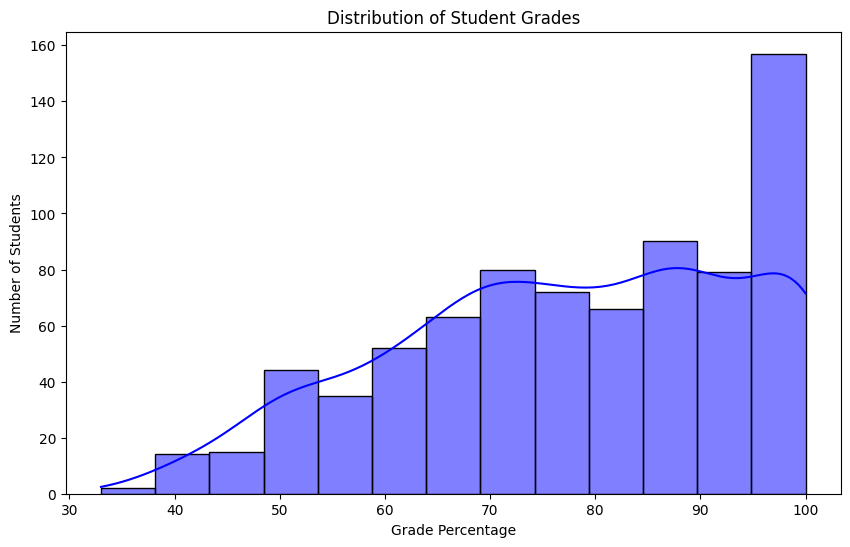

In [35]:
# plotting the distribution of grades
plt.figure(figsize=(10, 6))
# Using seaborn to create a histogram with a kernel density estimate (KDE) overlay
sns.histplot(df['Grade'], kde=True, color='blue')
# Adding title and labels
plt.title('Distribution of Student Grades')
plt.xlabel('Grade Percentage')
plt.ylabel('Number of Students')
# Display the plot
plt.show()

4. Data Normalization: "Grade" is out of 100, but "Sex" is only 0 or 1. Needs normalization.  

In [37]:
# We only normalize the columns that are numbers
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Show the first 5 rows of your "Normalized" data
print("Normalized Data (all values now between 0 and 1):")
print(df_scaled.head())

Normalized Data (all values now between 0 and 1):
   Sex  School Code  Playing Years  Playing Often  Playing Hours  \
0  0.0          0.0           0.25            0.4            0.2   
1  1.0          0.0           0.25            0.6            0.2   
2  0.0          0.0           0.00            0.0            0.0   
3  0.0          0.0           0.75            1.0            0.2   
4  1.0          0.0           0.25            0.2            0.4   

   Playing Games  Parent Revenue  Father Education  Mother Education     Grade  
0            0.5            1.00          0.666667          0.833333  0.664179  
1            0.5            0.25          0.500000          0.500000  0.746269  
2            0.0            0.25          0.500000          0.500000  0.701493  
3            0.5            0.50          0.333333          0.500000  0.179104  
4            0.5            0.25          0.500000          0.666667  0.776119  


5. Data Discretization: - We want to group Grades to Grade Level and categorize them into Low,Good,Average,Excelent 

In [39]:
# Define the bins (the cut-off points) and the labels
bins = [0, 60, 75, 90, 100]
labels = ['Low', 'Average', 'Good', 'Excellent']

# Create the new column
df['Grade_Level'] = pd.cut(df['Grade'], bins=bins, labels=labels)

# Check the first few rows to see the new "bucketed" column
print(df[['Grade', 'Grade_Level']].head())

   Grade Grade_Level
0   77.5        Good
1   83.0        Good
2   80.0        Good
3   45.0         Low
4   85.0        Good


* Since we have a large number of data, We can show the count of categories 

In [42]:
# This shows the total count for each category
print(df['Grade_Level'].value_counts())

Grade_Level
Good         230
Average      208
Excellent    184
Low          147
Name: count, dtype: int64


6. Data Reduction: Linear Regression
    * We are going to see if "Playing Hours" (our "X" variable) can predict the "Grade" (our "Y" variable).

In [43]:
from sklearn.linear_model import LinearRegression

# 1. Prepare the data
# We use [[ ]] because the model expects a 2D array for X
X = df[['Playing Hours']] 
y = df['Grade']

# 2. Create and "Train" the model
model = LinearRegression()
model.fit(X, y)

# 3. Get the results
slope = model.coef_[0]
intercept = model.intercept_

print(f"For every 1 hour of gaming, the grade changes by: {slope:.2f} points")
print(f"The 'starting' grade (intercept) is: {intercept:.2f}")

For every 1 hour of gaming, the grade changes by: -1.95 points
The 'starting' grade (intercept) is: 80.40


*NOW we can Visualize it  

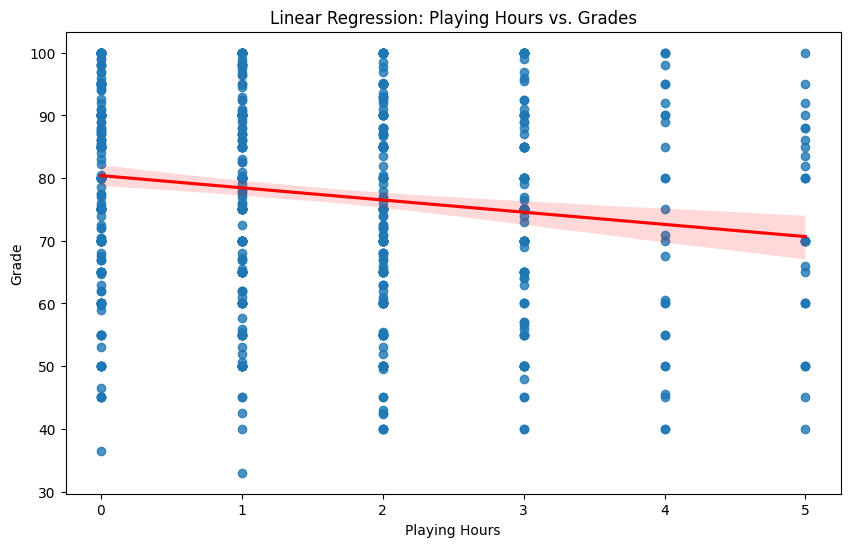

In [44]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Playing Hours', y='Grade', data=df, line_kws={"color": "red"})
plt.title('Linear Regression: Playing Hours vs. Grades')
plt.show()

* Negative correlation: So as a result we can see that "Playing Hours" increase, the red line goes down, suggesting that more gaming time is linked to slightly lower grades.

7. Multiple Regression: "big brother" of linear Regression. It is going to look everything at once. 

In [45]:
# 1. Select all numerical columns as predictors (X)
# We drop 'Grade' (the result) and 'Grade_Level' (the text category)
X_multi = df.drop(['Grade', 'Grade_Level'], axis=1)
y_multi = df['Grade']

# 2. Create and train the Multiple Regression model
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

# 3. See which factor has the most "weight"
coefficients = pd.DataFrame(multi_model.coef_, X_multi.columns, columns=['Weight'])
print("How much each factor affects the Grade:")
print(coefficients.sort_values(by='Weight', ascending=False))

How much each factor affects the Grade:
                     Weight
Mother Education   3.343266
Father Education   2.151722
Playing Often      1.906095
School Code        1.050281
Playing Years      0.507266
Parent Revenue    -0.051725
Playing Hours     -0.324973
Sex               -2.896688
Playing Games    -10.025944


* Mother/Father Education (+3.34 and +2.15): These are your strongest positive predictors. For every level of education the parents have, the student's grade tends to go up by 2–3 points.

* Playing Games (-10.02): This is a huge discovery! This "weight" suggests that the type or presence of gaming has a much bigger negative impact than just the "hours" alone.

* Parent Revenue (-0.05): This is almost zero. This tells you that money does not affect grades in this specific dataset.

8. Attribute Subset Selection: We can drop that has almost zero impact, so the model gets simplified without losing accuracy.

In [46]:
# Dropping the column that doesn't matter (Data Reduction)
df_reduced = df.drop(['Parent Revenue', 'School Code'], axis=1)

print("Columns remaining after Attribute Selection:")
print(df_reduced.columns)

Columns remaining after Attribute Selection:
Index(['Sex', 'Playing Years', 'Playing Often', 'Playing Hours',
       'Playing Games', 'Father Education', 'Mother Education', 'Grade',
       'Grade_Level'],
      dtype='str')


9. Clustering using K-Means: This will group students into "profiles" ("High-Achievers" vs. "Heavy Gamers") automatically.

In [48]:
from sklearn.cluster import KMeans

# 1. Initialize the model
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit the model using ONLY the scaled numbers
# We don't need to 'drop' anything because df_scaled is already just numbers!
df['Cluster'] = kmeans.fit_predict(df_scaled)

# 3. See the results
print("Students grouped into 3 Clusters:")
print(df['Cluster'].value_counts())

Students grouped into 3 Clusters:
Cluster
0    331
1    227
2    211
Name: count, dtype: int64


In [49]:
# This shows the average Grade for each cluster
print(df.groupby('Cluster')['Grade'].mean())

Cluster
0    75.007583
1    81.546123
2    77.057109
Name: Grade, dtype: float64


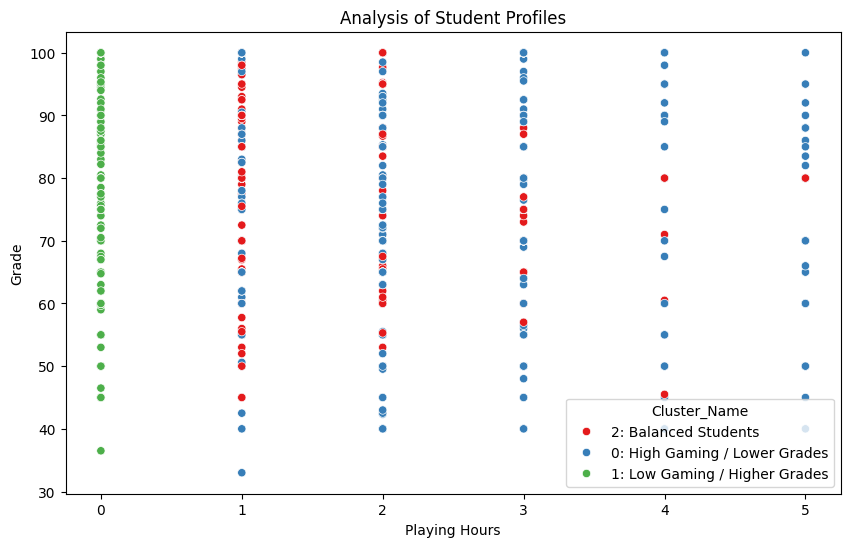

In [52]:
# Create a dictionary to map numbers to names
cluster_names = {
    0: '0: High Gaming / Lower Grades',
    1: '1: Low Gaming / Higher Grades',
    2: '2: Balanced Students'
}

# Apply the names to a new column
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# Now run your simple plot again, but use hue='Cluster_Name'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Playing Hours', y='Grade', hue='Cluster_Name', data=df, palette='Set1')
plt.title('Analysis of Student Profiles')
plt.show()

10. Sampling: Taking 10% of slice of the data. 

In [54]:
# 'frac=0.1' means 10% of the data
# 'random_state=42' ensures you get the same "random" sample every time you run it
df_sample = df.sample(frac=0.1, random_state=42)

print(f"Original Dataset Size: {len(df)} rows")
print(f"Sampled Dataset Size: {len(df_sample)} rows")
print("\nFirst 5 rows of the sample:")
print(df_sample.head())

Original Dataset Size: 769 rows
Sampled Dataset Size: 77 rows

First 5 rows of the sample:
     Sex  School Code  Playing Years  Playing Often  Playing Hours  \
670    1           10              3              3              3   
324    0            4              2              1              2   
626    1            9              0              0              0   
692    0           11              0              0              0   
474    1            7              1              3              1   

     Playing Games  Parent Revenue  Father Education  Mother Education  Grade  \
670              1               3                 5                 5   90.0   
324              1               2                 3                 4   60.0   
626              0               0                 3                 3  100.0   
692              0               3                 3                 2   90.0   
474              1               0                 2                 2  100.0   

 